# Final Project

## The Data and Setup

In this section, all of the libraries and functions needed to complete this project were imported. From there, the dataset was read into the notebook. To ensure this worked, the first 5 rows of the dataset are shown.

In [141]:
%matplotlib inline
import numpy as np
import pandas as pd #pandas is a library with structures and operations  to data manipulation 
import matplotlib.pyplot as plt #matplotlib is a library to plotting
import seaborn as sns #seaborn is a library for statistical data visualization
from datetime import datetime
from scipy.stats import spearmanr #spearmanr is a method that returns the correlation between  numerical attributes 


#the dataset is in the current directory
#https://www.kaggle.com/datasets/aungpyaeap/supermarket-sales
#and for context, cogs = cost of goods

df = pd.read_csv('supermarket_sales.csv')
#Showing the first five rows 
df.head(5)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


The gross margin percentage will be dropped here, due to issues further on in the dataset. This could be due to a variety of reasons, but most likely the way the dataset is set out, as the type of variable is unable to be determined.

In [142]:
df = df.drop('gross margin percentage', axis=1)

### Dates

First, we examined what format the dates were in for the current dataset by displaying the first 10 rows. This is a bigger number than earlier, but this is so we can more accurately decifer the format.

From there, we  turn the date into a datetime format. Then display the first 5 rows of the column 'Date' again to make sure this has worked. You can see the slight difference in  formatting this way, so we can tell that it worked.

We data split the date so we have the month and the month name, once again printing the first 5 to ensure this worked.

From here, we can finally graph the number of sales per month. After getting the counts of the column "month_name", we sort the data.
In order for the graph to display in chronological order, we must define which order the months go in. A Histogram is made to display how sales differ between months.

There is a slight dip in Feburary's sales, however for the most part it is relatively consistent.

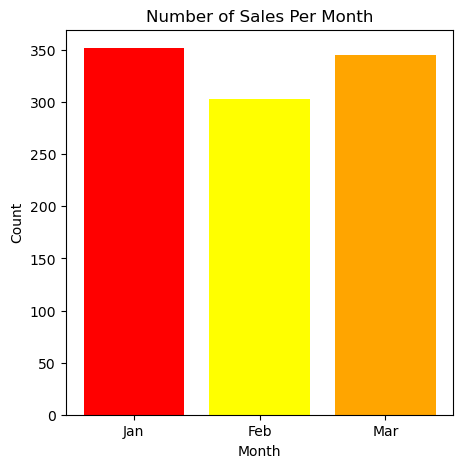

In [143]:
df['Date'].head(10)
#dates are in month/day/year


df['Date'] = pd.to_datetime(df['Date'])
df['Date'].head(5)

df['month'] = df.Date.dt.month
df['month_name'] = df['Date'].dt.month_name().str[:3]

df.head(5)

####NUMBER OF SALES PER MONTH###
#Get the counts 
month_counts = df['month_name']

#sort
months = ["Jan", "Feb", "Mar"]
df['month_name'] = pd.Categorical(df['month_name'], categories=months, ordered=True)
df.sort_values(by='month_name',inplace=True)


# Get the counts of each month
month_counts = df['month_name'].value_counts().sort_index()

# Figure size
plt.figure(figsize=(5, 5))

# Plotting
plt.bar(month_counts.index, month_counts.values, color=['red', 'yellow', 'orange'])

# Adding labels
plt.xlabel('Month')
plt.ylabel('Count')
plt.title('Number of Sales Per Month')

# Show plot
plt.show()




## Quantity vs Total Price

Next, I wanted to explore the quantity variable, and how that interacted with the total count.
First, a histogram was created to demonstrate how many times a certain number of items were bought. There is no discernable pattern between these two variables.

Next, I plotted the interaction between Quantity and Total Price. This was, almost expectedly, linear.

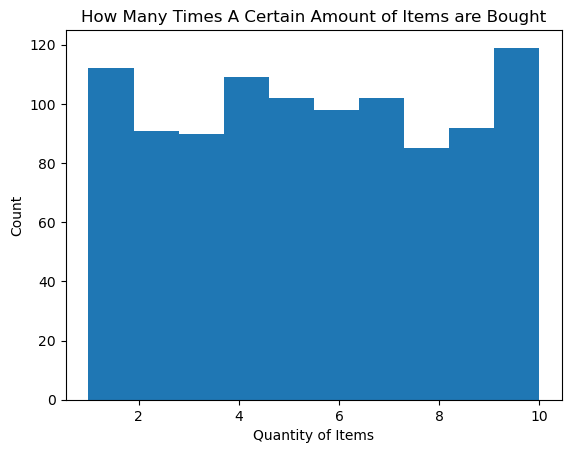

Text(0.5, 1.0, 'Quantity vs Total Price')

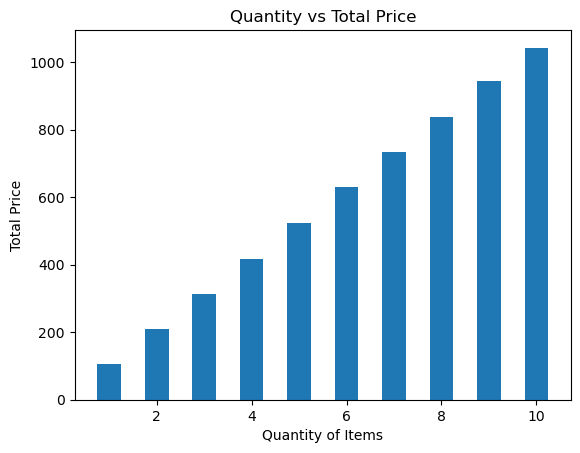

In [144]:
no_counts = df['Quantity']
total_counts = df['Total']

# Plotting
plt.hist(no_counts)

# Adding labels
plt.xlabel('Quantity of Items')
plt.ylabel('Count')
plt.title('How Many Times A Certain Amount of Items are Bought')

# Show plot
plt.show()

#Quantity vs Total Price
plt.bar('Quantity', 'Total', width=0.5, data=df)
plt.xlabel('Quantity of Items')
plt.ylabel('Total Price')
plt.title('Quantity vs Total Price')



## Taxation at Different Branches

I then wanted to see if different branches have different minimum tax amount. This was shown in a horizontal bar graph like below. All three are different from each other, but B does not have the highest maximum tax amount, which goes to Branch C. The Higher Average Total Price goes to Branch C, with Branch B coming in second and Branch A coming last.

Text(0.5, 1.0, 'Does One Branch Have a Higher Minimum Tax')

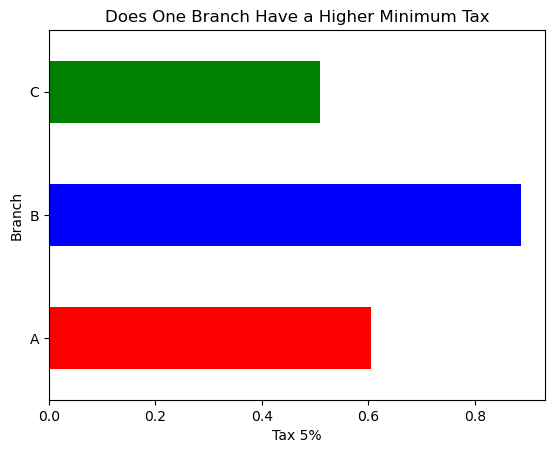

In [145]:
BranchTotalMin = df.groupby('Branch')['Tax 5%'].min()
BranchTotalMin.plot(kind='barh',  color=['red', 'blue', 'green'])
plt.xlabel('Tax 5%') 
plt.ylabel('Branch')
plt.title('Does One Branch Have a Higher Minimum Tax')

Text(0.5, 1.0, 'Does One Branch Have a Higher Maximum Tax')

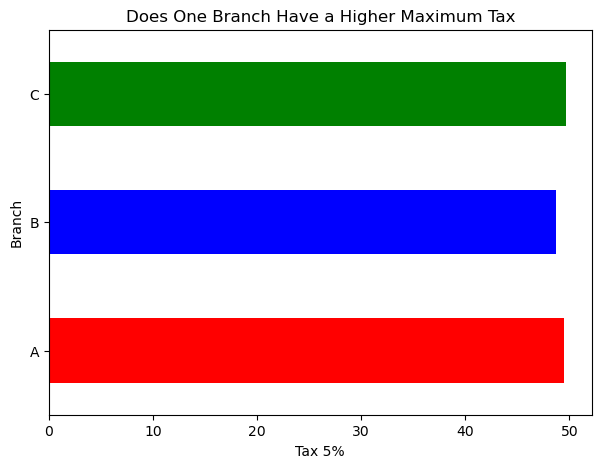

In [146]:
plt.figure(figsize=(7, 5))

BranchTotalMax = df.groupby('Branch')['Tax 5%'].max()
BranchTotalMax.plot(kind='barh',  color=['red', 'blue', 'green'])
plt.xlabel('Tax 5%') 
plt.ylabel('Branch')
plt.title('Does One Branch Have a Higher Maximum Tax')

Text(0.5, 1.0, 'Does One Branch Have a Higher Average Total Price')

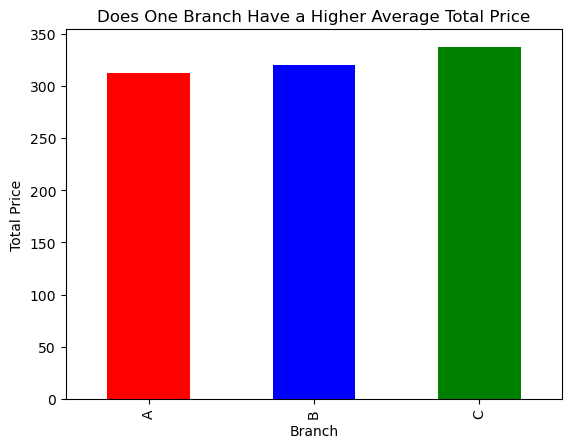

In [147]:
BranchTotalAve = df.groupby('Branch')['Total'].mean()
BranchTotalAve.plot(kind='bar',  color=['red', 'blue', 'green'])
plt.xlabel('Branch') 
plt.ylabel('Total Price')
plt.title('Does One Branch Have a Higher Average Total Price')

## Product Line Preferences By Gender

This section started off by sorting the data into two seperate counts, where both counts include the product line variable. The first count is where the gender is "Female" and the second where the gender is "Male". These counts were then sorted by the idenx.

The length of the one of the counts was calculated for ease of graphing. With a few minor adjustments to the width of the bars and the position of the bars on the x-axis, the two counts were plotted together. Labels and a legend was including for increased readability.

There is a obvious different for most product lines which gender prefers which. The only case where this is different is Home and Lifestyle and Electronic Accessories, where it is a lot closer to being even.


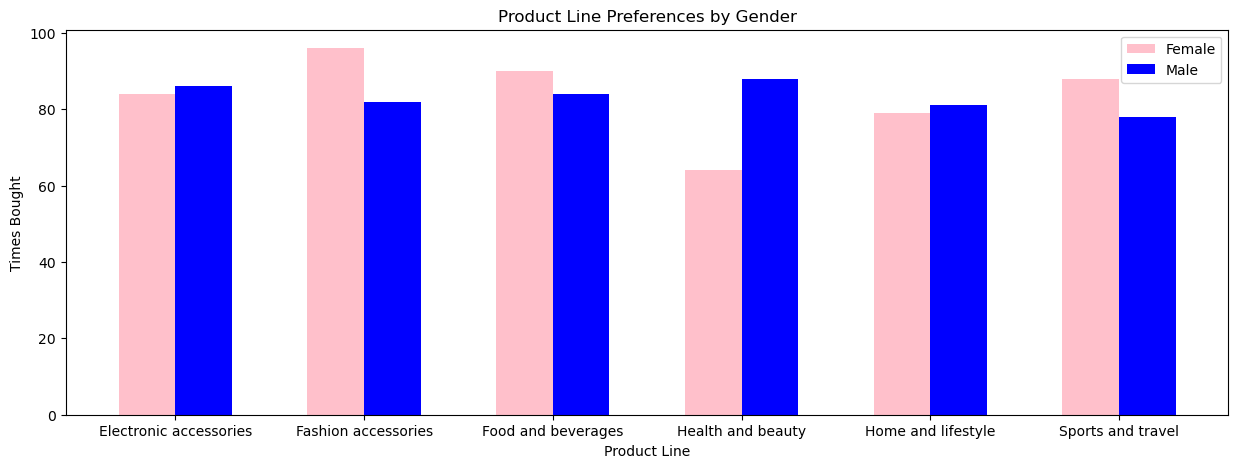

In [148]:
#Get the counts of both Female Product Line and Male Product Line
FemProduct_counts = df[df['Gender'] == 'Female']['Product line'].value_counts()
MaProduct_counts = df[df['Gender'] == 'Male']['Product line'].value_counts()

# Sort the counts
FemProduct_counts = FemProduct_counts.sort_index()
MaProduct_counts = MaProduct_counts.sort_index()

# Number of categories
N = len(FemProduct_counts)

# Position of bars on x-axis
ind = np.arange(N)

# Figure size
plt.figure(figsize=(15, 5))

# Width of a bar
width = 0.3

# Plotting
plt.bar(ind, FemProduct_counts, width, label='Female', color=['pink'])
plt.bar(ind + width, MaProduct_counts, width, label='Male', color=['blue'])

# Adding labels
plt.xlabel('Product Line')
plt.ylabel('Times Bought')
plt.title('Product Line Preferences by Gender')

# xticks
plt.xticks(ind + width / 2, FemProduct_counts.index) # titling the bars by which product line it is

# Finding the best position for legends and putting it
plt.legend(loc='best')

# Show plot
plt.show()


## Are women or men shopping at these stores more than the other? And which gender are buying the more expensive items?

To view this, we got the count of the column "Gender". Then it was a matter of plotting it into a pie chart. We can see that there is barely a difference in the proportion of genders shopping at these stores.

We then produced a box plot with total and gender as the two variables we were looking at. Females seem to be buying either more items and/or the more expensive times compared to males. The mean price is higher as well.

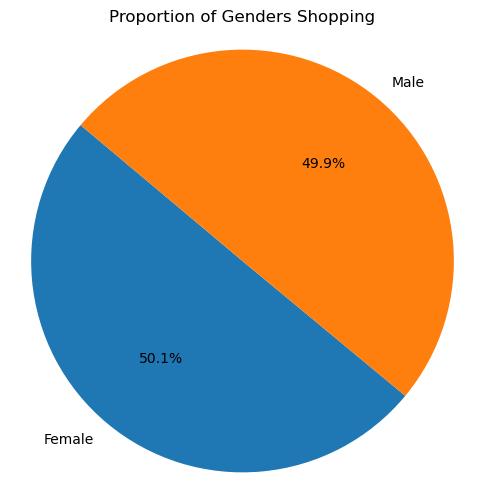

Text(0.5, 1.0, 'Total Price Variation Between Genders')

<Figure size 640x480 with 0 Axes>

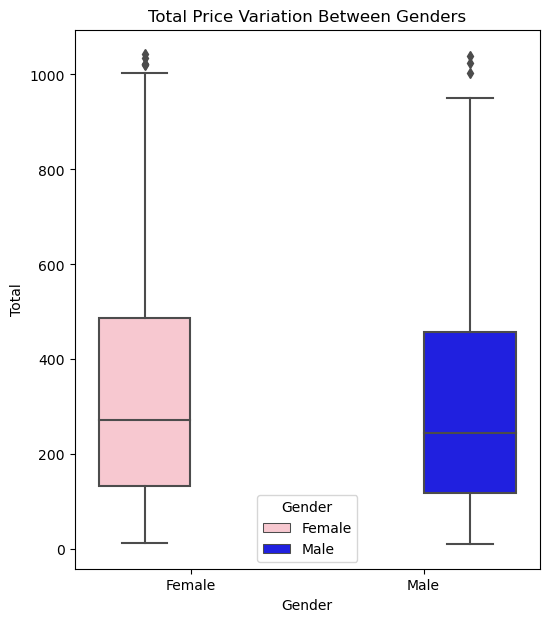

In [149]:
# Count the number of males/female who are shopping at these stores
gender_ratio_counts = df['Gender'].value_counts()


# Plotting the male pie chart
plt.figure(figsize=(6, 6))
plt.pie(gender_ratio_counts, labels=gender_ratio_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Proportion of Genders Shopping')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()



#Price of each product in $ by Gender
fig = plt.figure()


#figure size and colours
plt.figure(figsize=(6,7))
palette=['pink', 'blue']


# boxplot
sns.boxplot(x=df["Gender"], y=df["Total"], hue=df["Gender"], palette=palette).set_title('Total Price Variation Between Genders')


## Average Price Spent By Gender

The mean total price for each gender was calculated and displayed using a bar graph.
On average, females spend more than males.

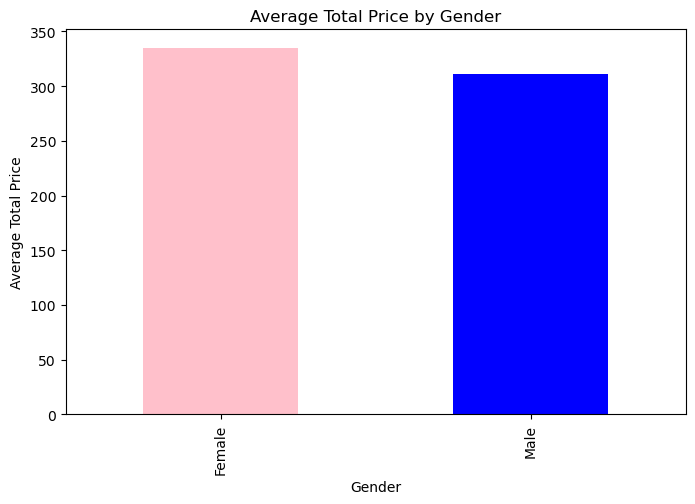

In [150]:
import pandas as pd
import matplotlib.pyplot as plt


#calculate the mean unit price for each gender
avg_unit_price_by_gender = df.groupby('Gender')['Total'].mean()

# Plotting
plt.figure(figsize=(8, 5))
avg_unit_price_by_gender.plot(kind='bar', color=['pink', 'blue'])

# Adding labels and title
plt.xlabel('Gender')
plt.ylabel('Average Total Price')
plt.title('Average Total Price by Gender')

# Show plot
plt.show()


## Proportion of Female and Male customers who are Rewards Members

The aim of this part was to find the proportion of female and male customers who are rewards members.
First, we found counts of female and male customer types.
To display this, we plotted both the female and male pie charts.

There is a minor difference with females more likely to be rewards members than males.

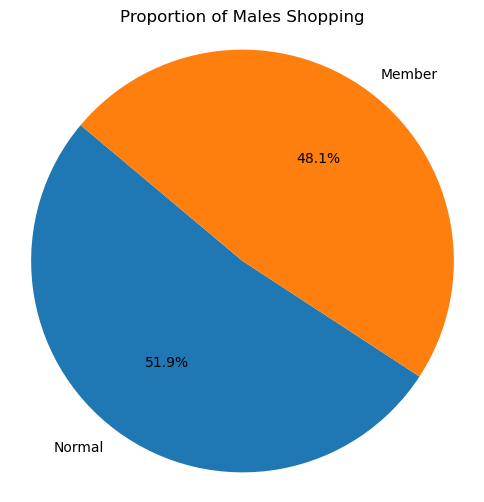

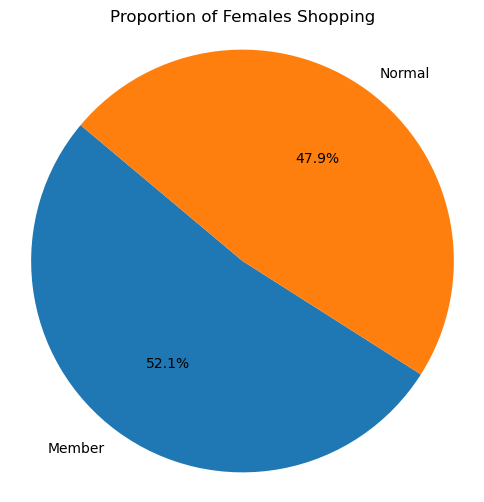

In [151]:
# Count the number of males/female who are rewards members/customer type
female_member_counts = df[df['Gender'] == 'Female']['Customer type'].value_counts()
male_member_counts = df[df['Gender'] == 'Male']['Customer type'].value_counts()


# Plotting the male pie chart
plt.figure(figsize=(6, 6))
plt.pie(male_member_counts, labels=male_member_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Proportion of Males Shopping')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# Plotting the female pie chart
plt.figure(figsize=(6, 6))
plt.pie(female_member_counts, labels=female_member_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Proportion of Females Shopping')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()



## Branches

This dataset is composed of three different branches. This part aimed to see if there was a branch all customers prefered, and then if different genders had a prefered branch.

This was done by getting the counts of the column 'Branch' with and without each gender. Then using similar techniques to Product Line Preferences By Gender, a bar graph was plotted showing the differences in how many men and women visited each branch, as well as the overall average without taking into account gender.


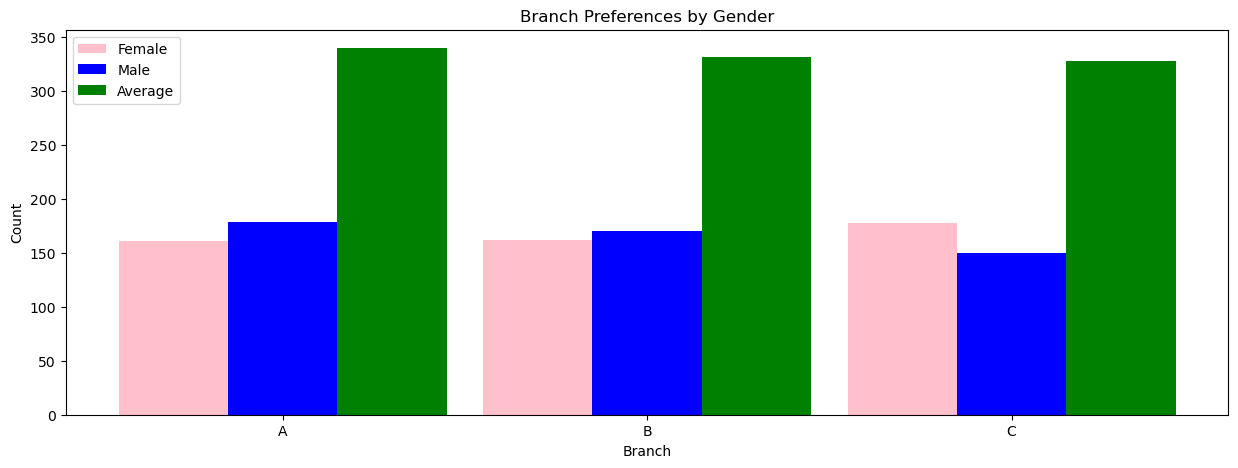

In [152]:
#Get the counts of both Female Product Line and Male Product Line
FemCus_counts = df[df['Gender'] == 'Female']['Branch'].value_counts()
MaCus_counts = df[df['Gender'] == 'Male']['Branch'].value_counts()
AllCus_counts = df['Branch'].value_counts()

# Sort the counts
FemCus_counts = FemCus_counts.sort_index()
MaCus_counts = MaCus_counts.sort_index()
AllCus_counts = AllCus_counts.sort_index()

# Number of categories
N = len(AllCus_counts)

# Position of bars on x-axis
ind = np.arange(N)

# Figure size
plt.figure(figsize=(15, 5))

# Width of a bar
width = 0.3

# Plotting
plt.bar(ind, FemCus_counts, width, label='Female', color=['pink'])
plt.bar(ind + width, MaCus_counts, width, label='Male', color=['blue'])
plt.bar(ind + 2 * width, AllCus_counts, width, label='Average', color=['green'])

# Adding labels
plt.xlabel('Branch')
plt.ylabel('Count')
plt.title('Branch Preferences by Gender')

# xticks
plt.xticks(ind + width, FemCus_counts.index) # titling the bars by which product line it is

# Finding the best position for legends
plt.legend(loc='best')

# Show plot
plt.show()

## Pair Plot

First, all of the numerical columns are found.
Then a pair plot including all of these columns is created.
A pair plot represents the relationship between two variables. The closer the data is to a line, the more related the two varables are.
The variables chosen are all of the quantitative variables.

Some of these plots are obviously linear, some are meant to be categorical, and some have no discernable pattern whatsoever.

In [153]:
#find the numerical columns (attributes)
numerical_columns = [n for n,col in df.items() if pd.api.types.is_numeric_dtype(col)]
numerical_columns

['Unit price',
 'Quantity',
 'Tax 5%',
 'Total',
 'cogs',
 'gross income',
 'Rating',
 'month']

C:\Users\georg\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


Text(0.5, 1.02, 'Pair Plot of Numerical Columns')

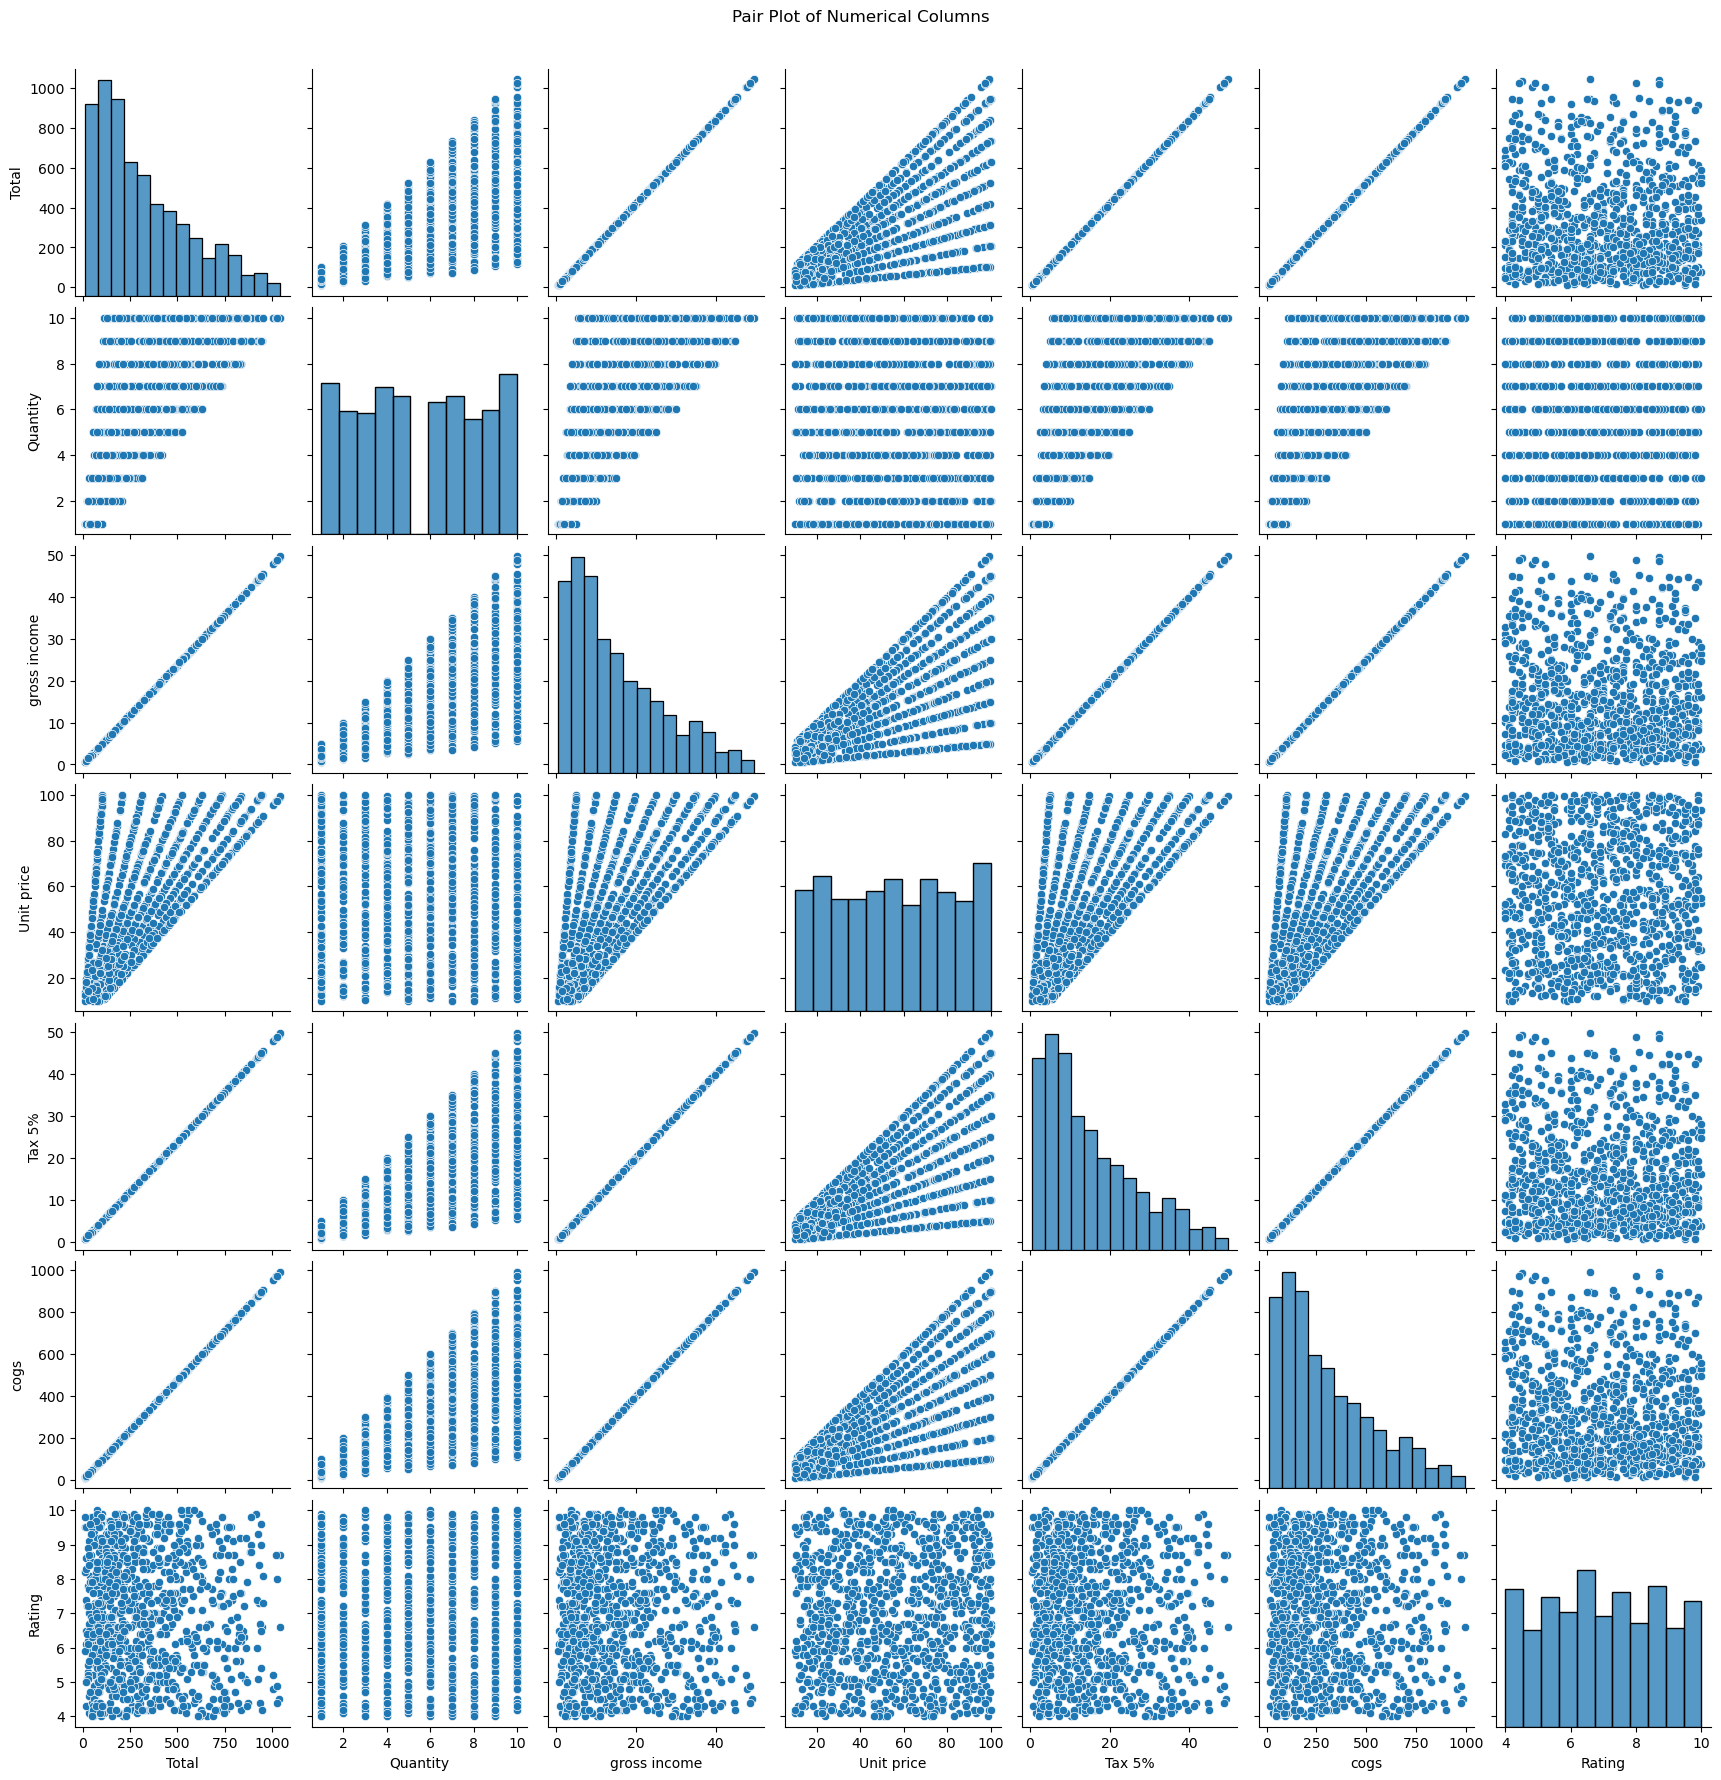

In [154]:
pp = sns.pairplot(df[['Total','Quantity', 'gross income', 'Unit price', 'Tax 5%', 'cogs', 'Rating']])

pp.fig.suptitle("Pair Plot of Numerical Columns", y=1.02) # y= some height>1

## Correlation Between Variables

Getting the correlations between pairs of the numerical variables within the dataset.
There seems to be a decent amount of perfect correlation (1). Considering these variables seem to be Tax 5%, Total, cogs and gross income, this is an expected value. Everything else has a relatively high corelation (between 0.63 and 0.74) apart from Quantity vs Unit Price and anything related to rating.


In [155]:

#Getting the correlations between pair of columns 
corr = spearmanr(df[numerical_columns].dropna()).correlation
corr

array([[ 1.        ,  0.01116701,  0.63005411,  0.63005411,  0.63005411,
         0.63005411, -0.00833519, -0.02626032],
       [ 0.01116701,  1.        ,  0.73526531,  0.73526531,  0.73526531,
         0.73526531, -0.01545298, -0.01480633],
       [ 0.63005411,  0.73526531,  1.        ,  1.        ,  1.        ,
         1.        , -0.01722593, -0.02328713],
       [ 0.63005411,  0.73526531,  1.        ,  1.        ,  1.        ,
         1.        , -0.01722593, -0.02328713],
       [ 0.63005411,  0.73526531,  1.        ,  1.        ,  1.        ,
         1.        , -0.01722593, -0.02328713],
       [ 0.63005411,  0.73526531,  1.        ,  1.        ,  1.        ,
         1.        , -0.01722593, -0.02328713],
       [-0.00833519, -0.01545298, -0.01722593, -0.01722593, -0.01722593,
        -0.01722593,  1.        , -0.04171669],
       [-0.02626032, -0.01480633, -0.02328713, -0.02328713, -0.02328713,
        -0.02328713, -0.04171669,  1.        ]])

## Heat Map using Correlation

Using the correlation just found, we can get a heatmap depicting the correlation between each pair of variables. A description of the plot can be seen above.

In [1]:
# To manage subplots 
plt.figure(figsize=(7,6)) #Setting a size in the plot
hm = sns.heatmap(corr, annot=True, fmt='.2f', linewidths=.5,
           xticklabels=numerical_columns, yticklabels=numerical_columns, cmap="BuPu")
hm.set_title('Heat Map Showing Correlation')

NameError: name 'plt' is not defined